In [ ]:
%run scripts/verify_environment.py

verify_environment()

In [ ]:
from getpass import getpass

admin_rdm_url = 'https://admin.bh.rdm.yzwlab.com/' # 'https://admin.staging.rdm.example.com'
idp_name_project_limit_1 = None
institution_name_project_limit_1 = None

# 統合管理者用 (manager)
idp_name_integrated_admin = None
idp_username_integrated_admin = None
idp_password_integrated_admin = None

default_result_path = None
close_on_fail = False
transition_timeout = 30000

In [ ]:
if idp_name_project_limit_1 is None:
    idp_name_project_limit_1 = input(prompt=f'IdP Name: ')
    
if institution_name_project_limit_1 is None:
    institution_name_project_limit_1 = input(prompt=f'Institution Name: ')
    
if idp_name_integrated_admin is None:
    idp_name_integrated_admin = input(prompt=f'IdP Name for integrated admin: ')
if idp_username_integrated_admin is None:
    idp_username_integrated_admin = input(prompt=f'Username for {idp_name_integrated_admin} (integrated admin)')
if idp_password_integrated_admin is None:
    idp_password_integrated_admin = getpass(prompt=f'Password for {idp_username_integrated_admin}@{idp_name_integrated_admin}')

In [ ]:
import tempfile

work_dir = tempfile.mkdtemp()
if default_result_path is None:
    default_result_path = work_dir
work_dir

# プロジェクト制限数_ルール作成・変更・削除(切り戻し①)

- サブシステム名: プロジェクト制限数
- ページ/アドオン: ルール作成・変更・削除
- 機能分類: ルール
- シナリオ名: プロジェクト制限数のルール作成・変更・削除
- 用意するテストデータ: URL一覧、アカウント(統合管理者既存ユーザー: GRDM)

In [ ]:
import importlib

import scripts.playwright
importlib.reload(scripts.playwright)

from scripts.playwright import *
from scripts import grdm

await init_pw_context(close_on_fail=close_on_fail, last_path=default_result_path)

## ウェブブラウザの新規プライベートウィンドウで GRDM 管理者トップページを表示する

GRDM 管理者トップページが表示されること


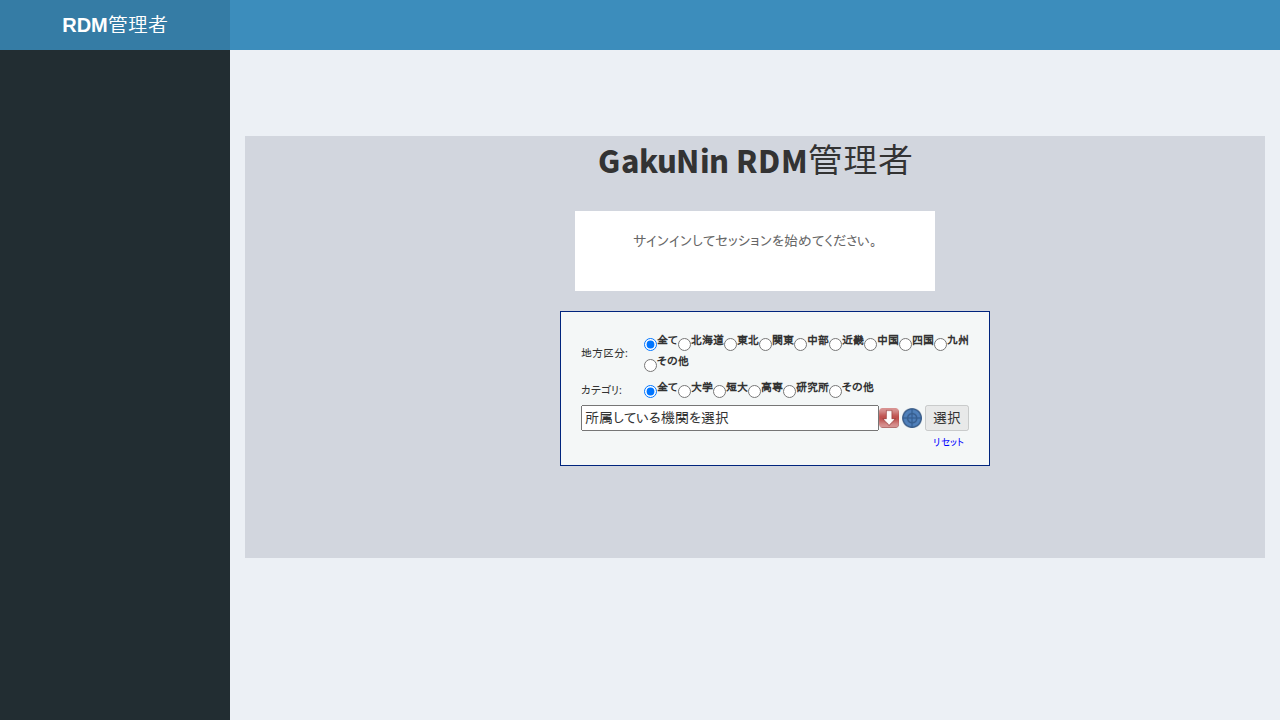

In [6]:
async def _step(page):
    await page.goto(admin_rdm_url)

    await expect(page.locator('.login-logo')).to_be_visible(timeout=transition_timeout)

await run_pw(_step)

## アカウント(統合管理者既存ユーザー)を用いてGakuNin RDMにログインする

(IdPに関するログイン情報が与えられた場合、)
GakuNin Embeded DSのプルダウンを展開し、IdPリストから指定されたIdPを選択する。その後、アカウントのID/Passwordを入力して「Login」ボタンを押下する。

(IdPが指定されていない場合、)
CASのログイン操作を実施する。


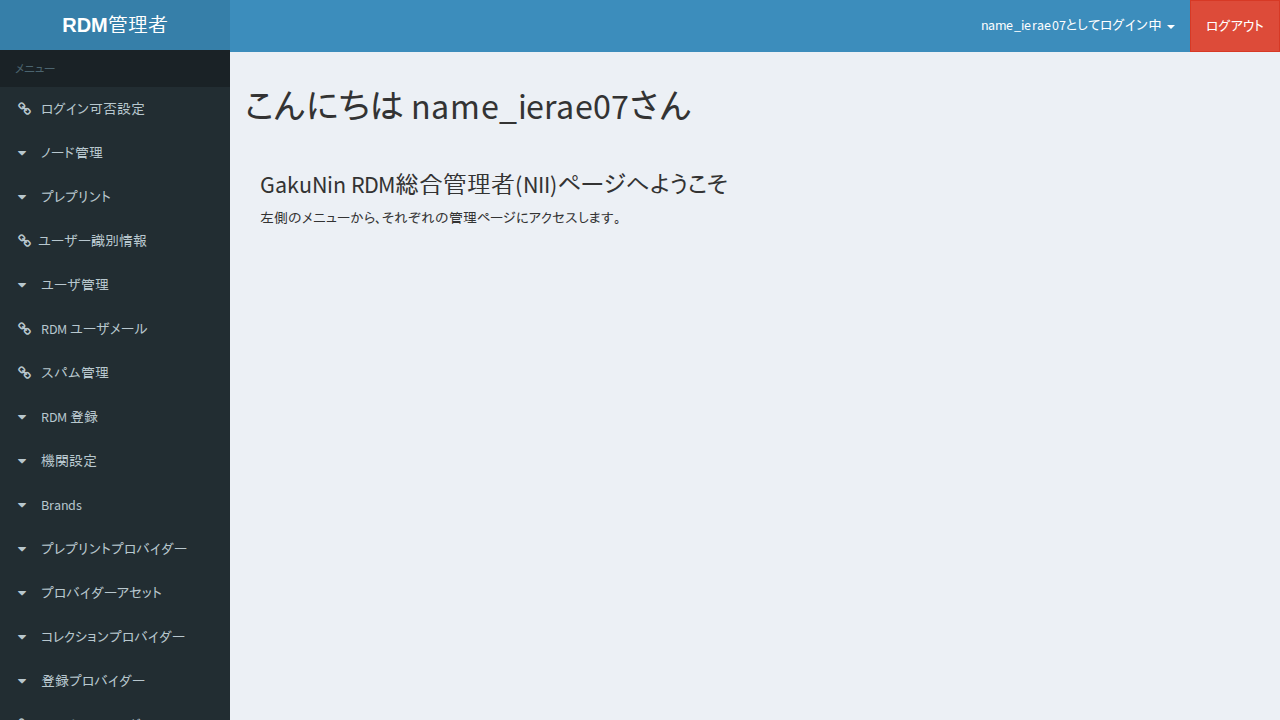

In [7]:
async def _step(page):
    await scripts.grdm.login_as_admin(
        page, idp_name_integrated_admin, idp_username_integrated_admin, idp_password_integrated_admin, transition_timeout=transition_timeout
    )

    await expect(page.locator('//*[contains(@class, "btn-danger") and contains(text(), "ログアウト")]')).to_be_enabled(timeout=transition_timeout)

await run_pw(_step)

## メニューから「プロジェクト制限数」をクリックする

「設定テンプレート」「設定」のサブメニューが表示されること


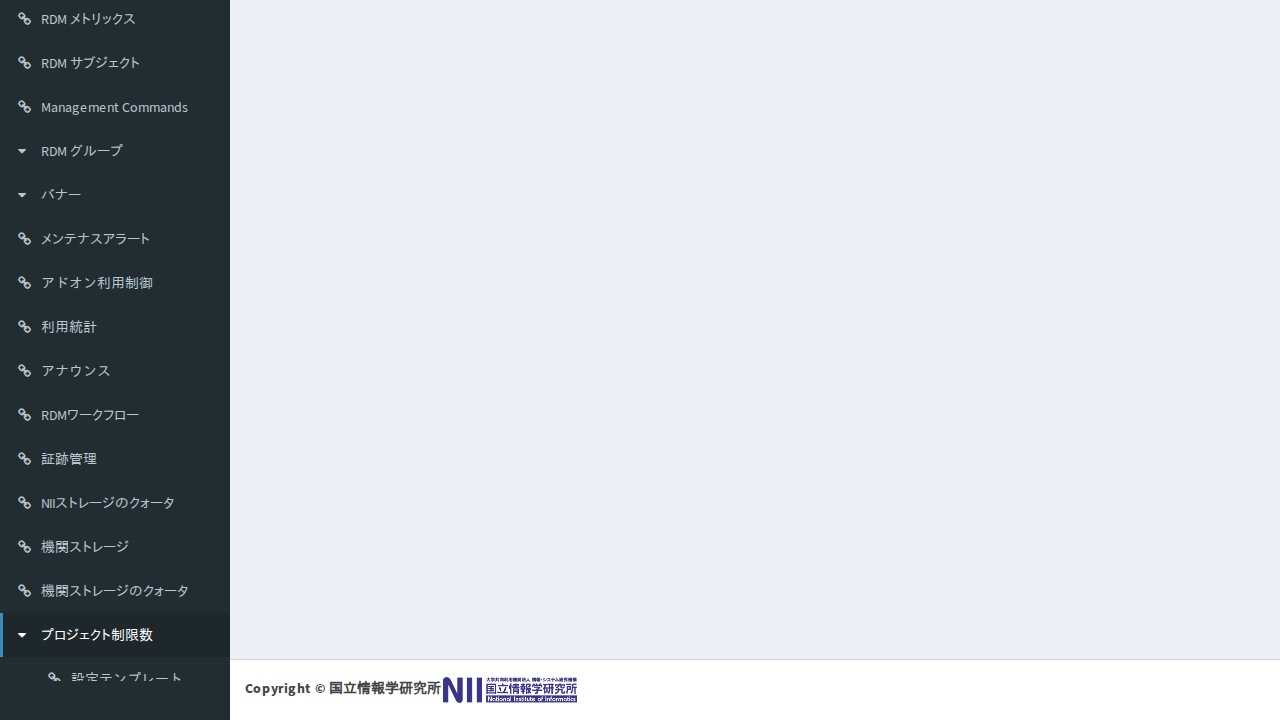

In [8]:
async def _step(page):
    await page.locator('//a[@href = "#collapseProjectLimitNumber"]').click()

    await expect(page.locator('//a[@href = "/project_limit_number/templates/"]')).to_be_visible(timeout=transition_timeout)
    await expect(page.locator('//a[@href = "/project_limit_number/settings/"]')).to_be_visible(timeout=transition_timeout)

await run_pw(_step)

## サブメニューから「設定」をクリックする

「プロジェクト作成数設定一覧」画面が表示されること


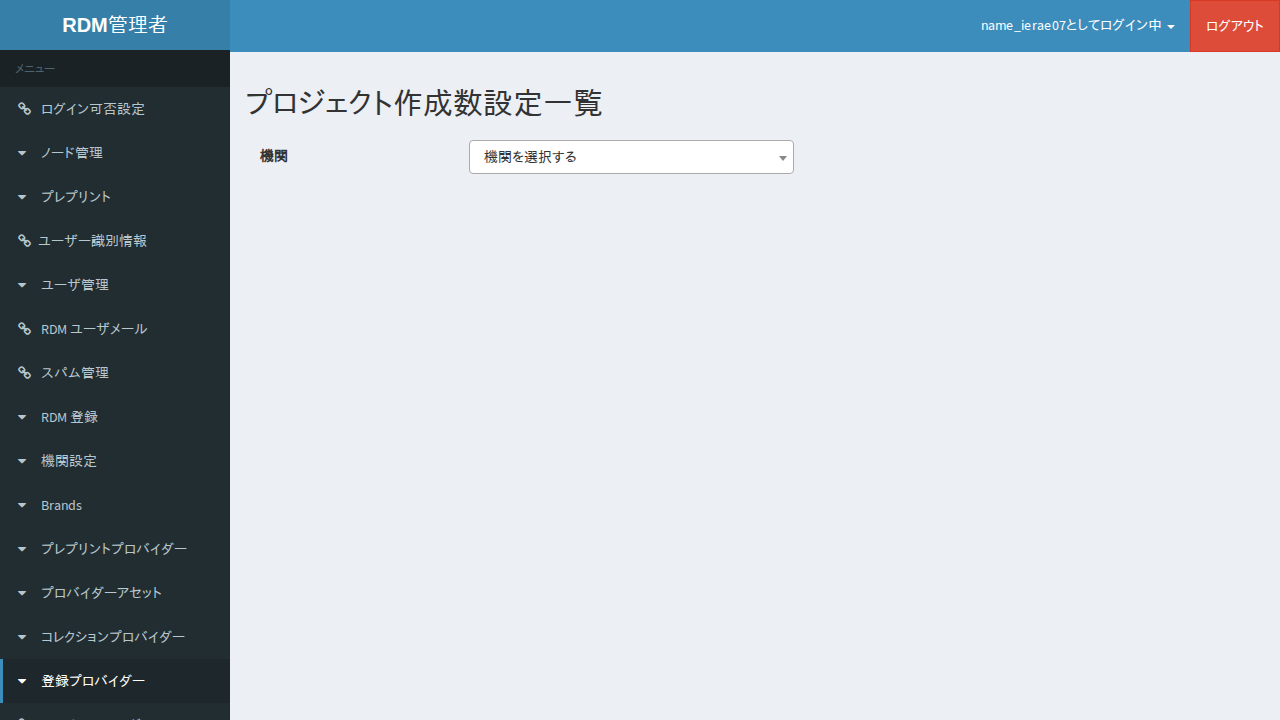

In [9]:
async def _step(page):
    await page.locator('//a[@href = "/project_limit_number/settings/"]').click()

    await expect(page.locator('//h2[text() = "プロジェクト作成数設定一覧"]')).to_be_visible(timeout=transition_timeout)

await run_pw(_step)

## 「機関」の「機関を選択する」をクリックし、「テンプレート作成・変更・削除」シートのNo. 2 のユーザが所属する機関を選択する

「プロジェクト制限のデフォルト」以下の項目が表示されること


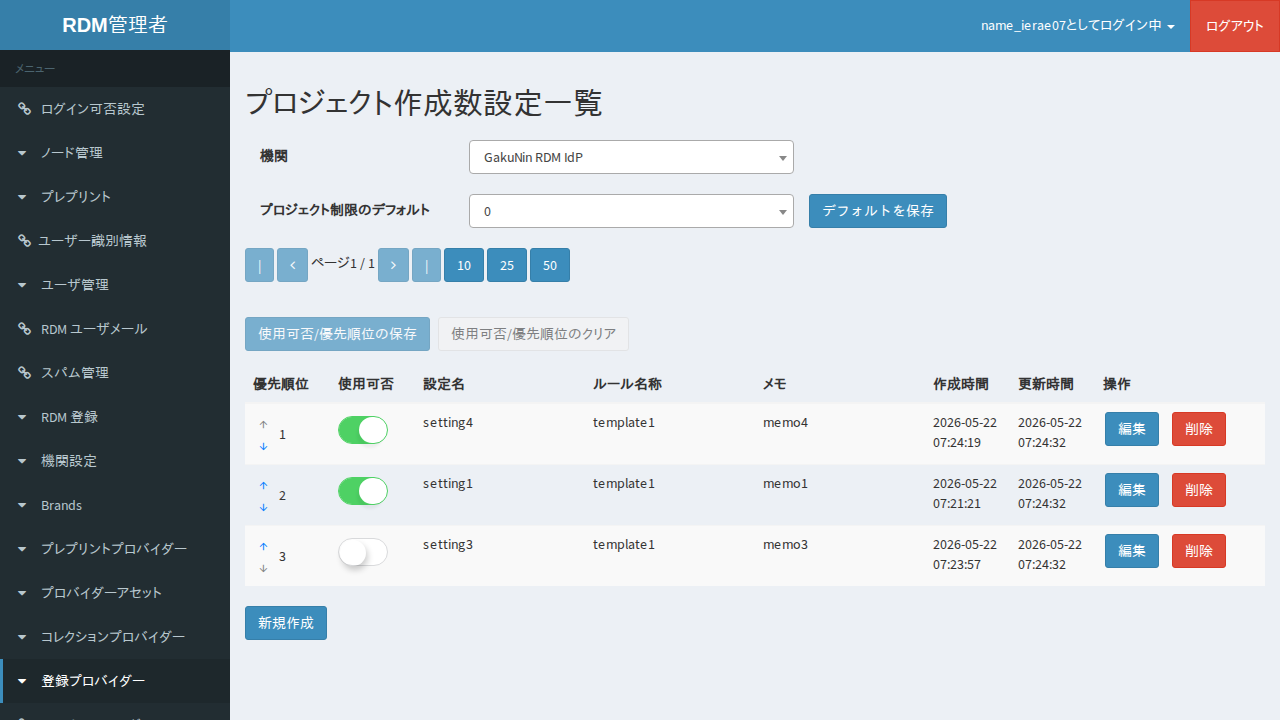

In [ ]:
async def _step(page):
    await page.locator('#institution_id').select_option(label=f'{institution_name_project_limit_1}')
    
    # 「プロジェクト制限のデフォルト」以下の項目が表示されることを確認
    await expect(page.locator('#project_limit_number_default_id')).to_be_visible(timeout=transition_timeout)
    await expect(page.locator('button', has_text='デフォルトを保存')).to_be_visible(timeout=transition_timeout)
    await expect(page.locator('#save_changes_button')).to_be_visible(timeout=transition_timeout)
    await expect(page.locator('#clear_changes_button')).to_be_visible(timeout=transition_timeout)
    await expect(page.locator('#setting-table')).to_be_visible(timeout=transition_timeout)
    await expect(page.locator('a', has_text='新規作成')).to_be_visible(timeout=transition_timeout)

await run_pw(_step)

## 「プロジェクト制限のデフォルト」のドロップダウンリストをクリックする

「無制限」「0」「1」...とドロップダウンリストが表示されること   
ドロップダウンリスト内の数値の最大値は admin/base/settings/defaults.py の PROJECT_LIMIT_NUMBER の値になっていること


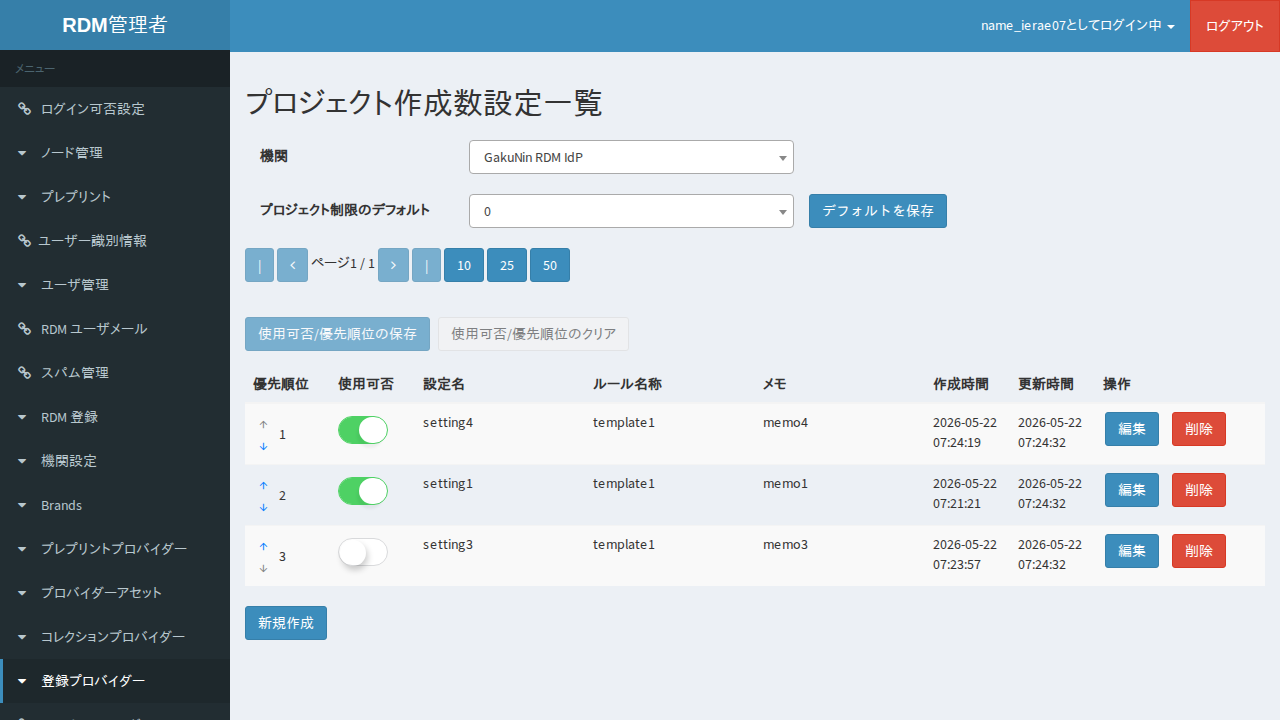

In [ ]:
async def _step(page):
    dropdown = page.locator('#project_limit_number_default_id')

    # 「無制限」「0」「1」... が表示されることを確認
    await expect(dropdown.locator('option[value="-1"]')).to_have_text('無制限', timeout=transition_timeout)
    await expect(dropdown.locator('option[value="0"]')).to_have_text('0', timeout=transition_timeout)
    await expect(dropdown.locator('option[value="1"]')).to_have_text('1', timeout=transition_timeout)
    await expect(dropdown.locator('option[value="10"]')).to_have_text('10', timeout=transition_timeout)

await run_pw(_step)

## 「プロジェクト制限のデフォルト」のドロップダウンリストの中から「5」を選択し、「デフォルトを保存」ボタンを押下する

「プロジェクト制限のデフォルト」が「5」になること


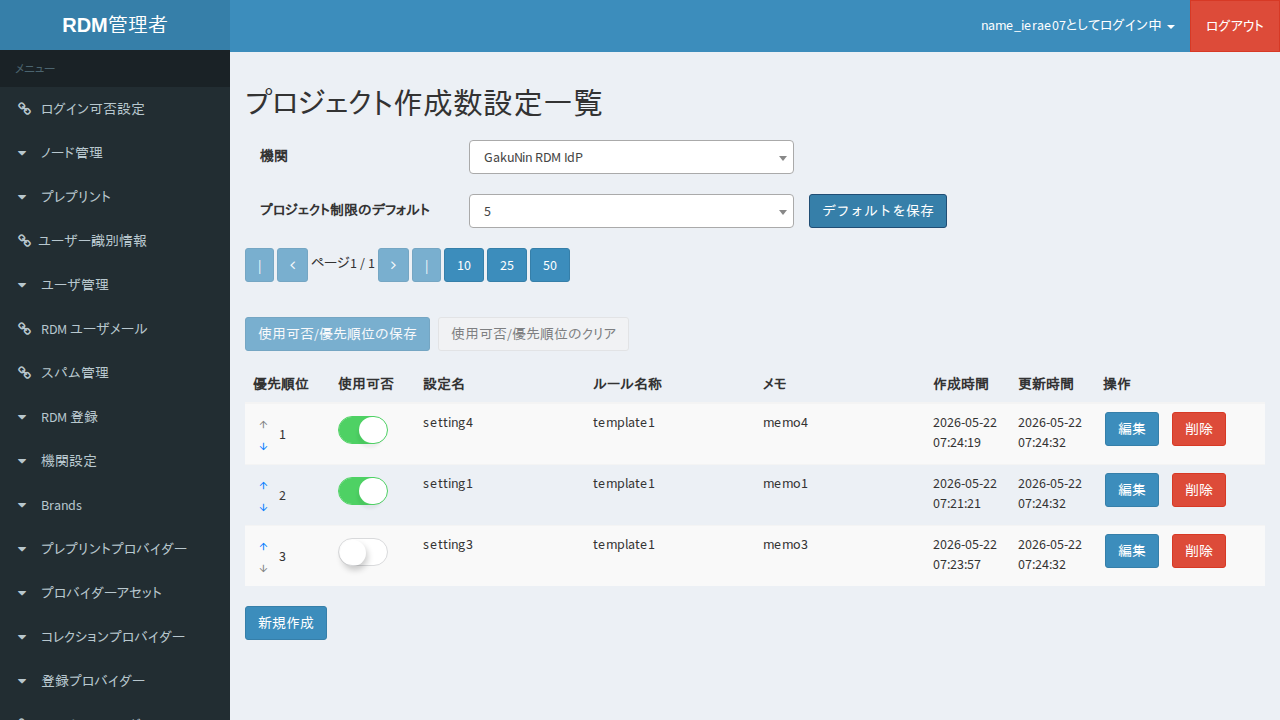

In [13]:
async def _step(page):
    # 「プロジェクト制限のデフォルト」で「5」を選択
    await page.locator('#project_limit_number_default_id').select_option('5')

    # 「デフォルトを保存」ボタンを押下し、保存後の再読み込み完了を待機
    async with page.expect_navigation(wait_until='load', timeout=transition_timeout):
        await page.locator('button', has_text='デフォルトを保存').click()

    # 「プロジェクト制限のデフォルト」が「5」になることを確認
    await expect(page.locator('#project_limit_number_default_id')).to_have_value('5', timeout=transition_timeout)

await run_pw(_step)

## 「ルール作成・変更・削除」シートの No.24 で保存した「設定名」の「setting1」の左にある「使用可否」のトグルボタンを押下する

「使用可否」のトグルボタンが変わり、「使用可否/優先順位の保存」と「使用可否/優先順位のクリア」が有効になること


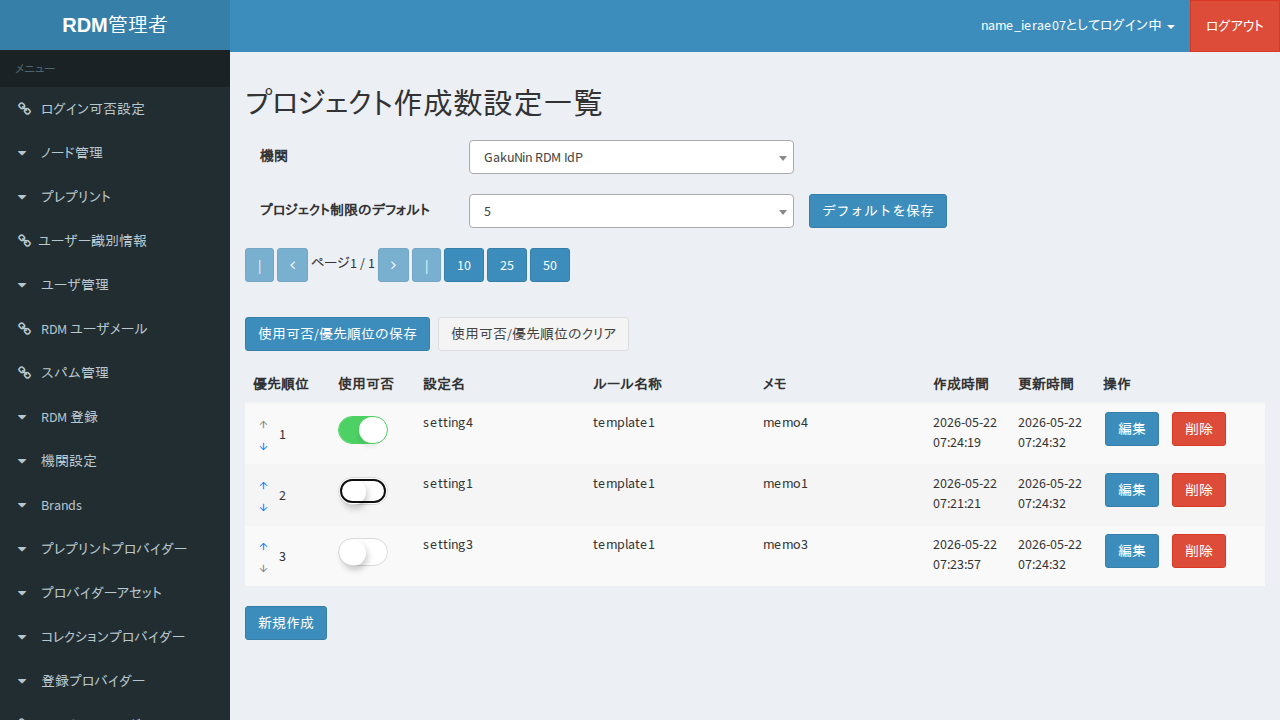

In [14]:
async def _step(page):
    # 「使用可否」のトグルボタンを押下
    row = page.locator('#setting-table tbody tr').filter(has_text='setting1')
    await row.locator('.setting-availability').click()

    # トグル状態が変更されること
    await expect(row.locator('.setting-availability')).to_have_value('off', timeout=transition_timeout)

    # 「使用可否/優先順位の保存」が有効になること
    await expect(page.locator('#save_changes_button')).to_be_enabled(timeout=transition_timeout)

    # 「使用可否/優先順位のクリア」が有効になること
    await expect(page.locator('#clear_changes_button')).to_be_enabled(timeout=transition_timeout)

await run_pw(_step)

## 「ルール作成・変更・削除」シートの No.39 で保存した「設定名」の「setting4」の左にある「使用可否」のトグルボタンを押下する

「使用可否」のトグルボタンが変わり、「使用可否/優先順位の保存」と「使用可否/優先順位のクリア」が有効になること


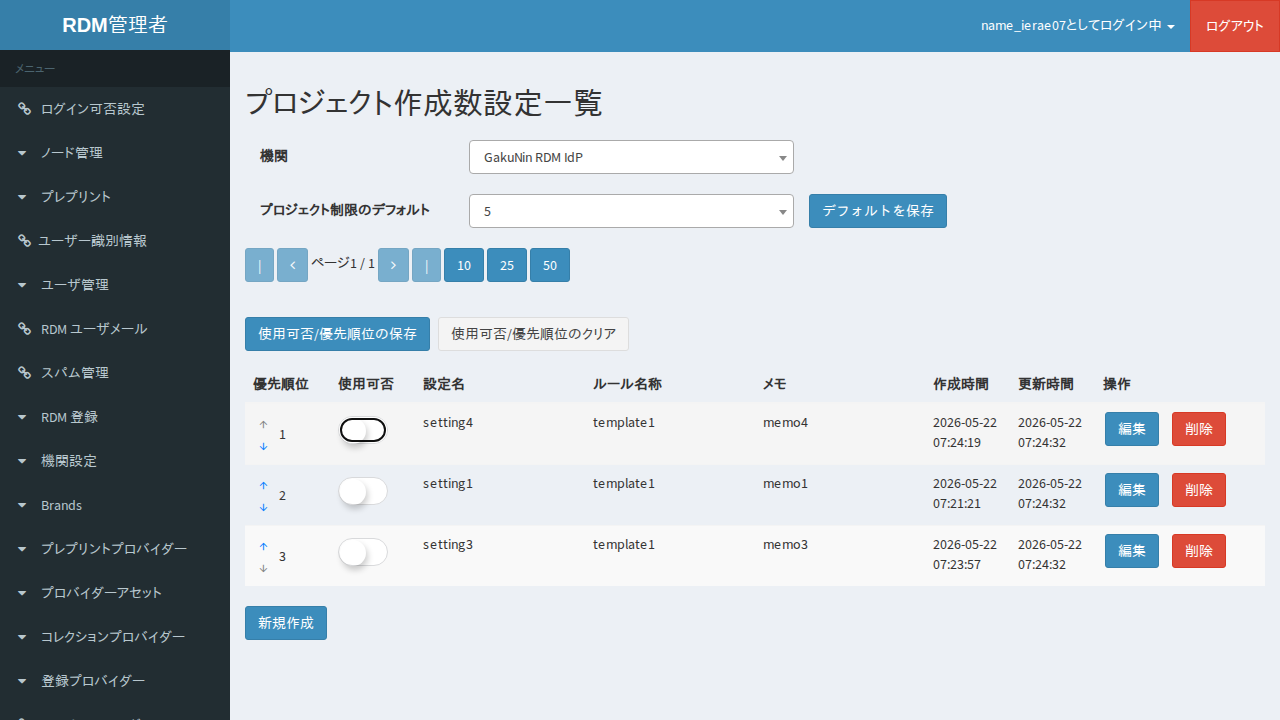

In [15]:
async def _step(page):
    # 「使用可否」のトグルボタンを押下
    row = page.locator('#setting-table tbody tr').filter(has_text='setting4')
    await row.locator('.setting-availability').click()

    # トグル状態が変更されること
    await expect(row.locator('.setting-availability')).to_have_value('off', timeout=transition_timeout)

    # 「使用可否/優先順位の保存」が有効になること
    await expect(page.locator('#save_changes_button')).to_be_enabled(timeout=transition_timeout)

    # 「使用可否/優先順位のクリア」が有効になること
    await expect(page.locator('#clear_changes_button')).to_be_enabled(timeout=transition_timeout)

await run_pw(_step)

## 「使用可否/優先順位の保存」ボタンを押下する

No.14 とNo.15 の「使用可否」のトグルボタンが確定し、「使用可否/優先順位の保存」と「使用可否/優先順位のクリア」が無効になること


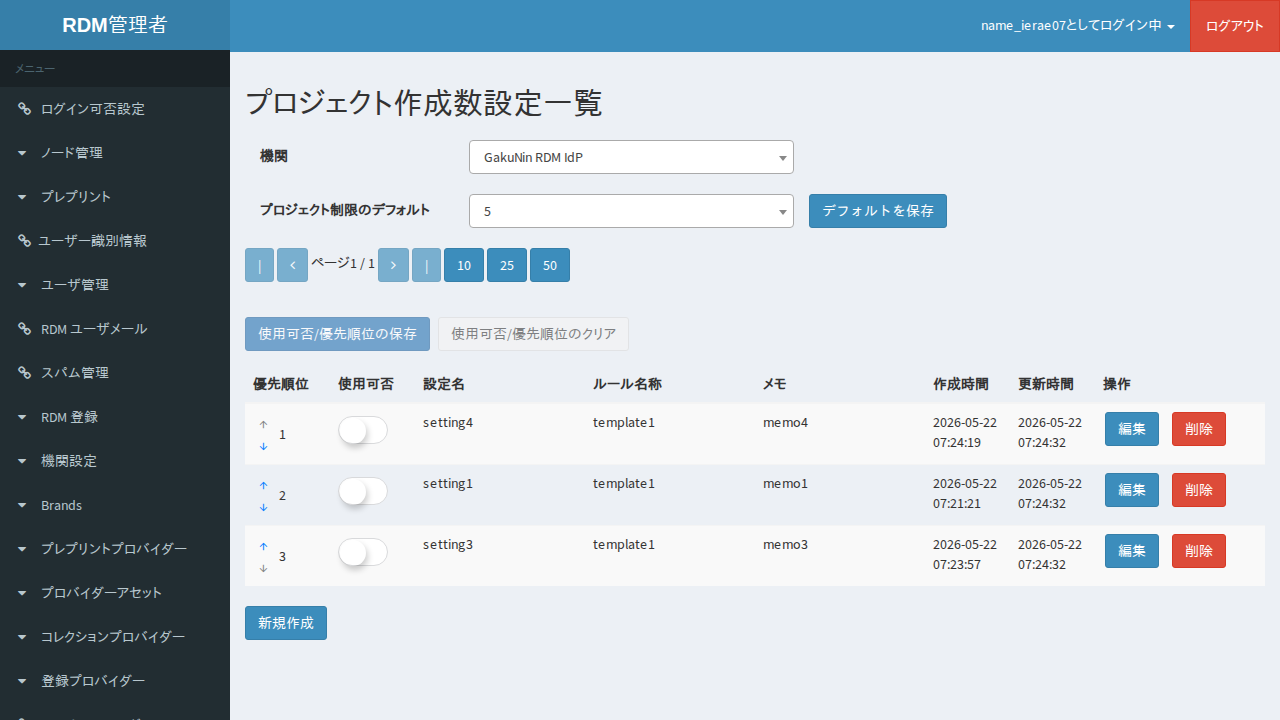

In [ ]:
async def _step(page):
   # 「使用可否/優先順位の保存」を押下し、保存後の再読み込み完了を待機
    async with page.expect_navigation(wait_until='load', timeout=transition_timeout):
        await page.locator('#save_changes_button').click()

    # 「setting1」の使用可否が確定していること（OFF）
    row_setting1 = page.locator('#setting-table tbody tr').filter(has_text='setting1')
    await expect(row_setting1.locator('.setting-availability')).to_have_value('off', timeout=transition_timeout)

    # 「setting4」の使用可否が確定していること（OFF）
    row_setting4 = page.locator('#setting-table tbody tr').filter(has_text='setting4')
    await expect(row_setting4.locator('.setting-availability')).to_have_value('off', timeout=transition_timeout)

    # 「使用可否/優先順位の保存」が無効になること
    await expect(page.locator('#save_changes_button')).to_be_disabled(timeout=transition_timeout)

    # 「使用可否/優先順位のクリア」が無効になること
    await expect(page.locator('#clear_changes_button')).to_be_disabled(timeout=transition_timeout)

await run_pw(_step)

終了処理を実施。

In [ ]:
await finish_pw_context()

In [ ]:
!rm -fr {work_dir}